In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd



In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.signal import stft
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


In [ ]:
!cp -r /content/drive/MyDrive/DatasetCSV /content/DatasetCSV


In [ ]:
DATASET_PATH = "/content/DatasetCSV"


In [ ]:
# WINDOW_SIZE = 200
# STEP_SIZE = 100

# def create_windows(data):
#     windows = []
#     for start in range(0, data.shape[0] - WINDOW_SIZE + 1, STEP_SIZE):
#         window = data[start:start + WINDOW_SIZE, :]
#         windows.append(window)
#     return


WINDOW_SIZE = 200
STEP_SIZE = 100

def create_windows(data):
    windows = []
    for start in range(0, data.shape[0] - WINDOW_SIZE + 1, STEP_SIZE):
        windows.append(data[start:start + WINDOW_SIZE])
    return windows

In [ ]:
total_windows = 0

for file in os.listdir(DATASET_PATH):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(DATASET_PATH, file))
        windows = create_windows(df.values)
        print(file, len(windows))
        total_windows += len(windows)

print("TOTAL WINDOWS:", total_windows)


Subj-9_Area-2_Act-2.csv 178
Subj-7_Area-2_Act-5.csv 178
Subj-9_Area-2_Act-7.csv 178
Subj-1_Area-3_Act-7.csv 178
Subj-10_Area-1_Act-5.csv 171
Subj-5_Area-1_Act-6.csv 178
Subj-10_Area-2_Act-1.csv 37
Subj-5_Area-1_Act-8.csv 178
Subj-4_Area-1_Act-6.csv 178
Subj-5_Area-3_Act-6.csv 178
Subj-9_Area-1_Act-9.csv 178
Subj-5_Area-2_Act-3.csv 178
Subj-3_Area-2_Act-3.csv 178
Subj-5_Area-2_Act-1.csv 39
Subj-1_Area-3_Act-1.csv 33
Subj-8_Area-2_Act-10.csv 178
Subj-4_Area-2_Act-7.csv 178
Subj-5_Area-2_Act-10.csv 178
Subj-9_Area-3_Act-10.csv 95
Subj-9_Area-2_Act-9.csv 178
Subj-8_Area-1_Act-7.csv 178
Subj-7_Area-1_Act-2.csv 79
Subj-3_Area-3_Act-5.csv 123
Subj-6_Area-2_Act-8.csv 127
Subj-3_Area-3_Act-3.csv 178
Subj-6_Area-3_Act-6.csv 179
Subj-1_Area-1_Act-2.csv 159
Subj-1_Area-1_Act-6.csv 131
Subj-10_Area-2_Act-9.csv 178
Subj-7_Area-3_Act-5.csv 178
Subj-7_Area-1_Act-4.csv 178
Subj-1_Area-3_Act-2.csv 178
Subj-7_Area-3_Act-9.csv 178
Subj-8_Area-2_Act-1.csv 36
Subj-9_Area-3_Act-5.csv 178
Subj-3_Area-3_Act-8.

In [ ]:
def extract_features(window):
    mean = np.mean(window, axis=0)
    var = np.var(window, axis=0)
    energy = np.sum(window ** 2, axis=0)
    return np.concatenate([mean, var, energy])


In [ ]:
for file in os.listdir(DATASET_PATH)[:10]:
    print(file)


Subj-9_Area-2_Act-2.csv
Subj-7_Area-2_Act-5.csv
Subj-9_Area-2_Act-7.csv
Subj-1_Area-3_Act-7.csv
Subj-10_Area-1_Act-5.csv
Subj-5_Area-1_Act-6.csv
Subj-10_Area-2_Act-1.csv
Subj-5_Area-1_Act-8.csv
Subj-4_Area-1_Act-6.csv
Subj-5_Area-3_Act-6.csv


In [ ]:
import re

def get_activity_label(filename):
    match = re.search(r"Act-(\d+)", filename)
    if match:
        return int(match.group(1)) - 1  # convert Act-1 → label 0
    else:
        raise ValueError(f"Activity label not found in {filename}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
X = []
y = []

for file in os.listdir(DATASET_PATH):
    if file.endswith(".csv"):
        label = get_activity_label(file)

        df = pd.read_csv(os.path.join(DATASET_PATH, file))
        data = df.values

        windows = create_windows(data)

        for w in windows:
            features = extract_features(w)
            X.append(features)
            y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)  # (47084, 1080)
print("y shape:", y.shape)  # (47084,)


X shape: (46880, 1080)
y shape: (46880,)


In [ ]:
print("Number of CSV files:", len([f for f in os.listdir(DATASET_PATH) if f.endswith(".csv")]))


Number of CSV files: 300


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

NameError: name 'train_test_split' is not defined

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
print("Classical ML Accuracy:", accuracy_score(y_test, y_pred))

Classical ML Accuracy: 0.9905076791808873


In [ ]:
print("\nTesting Classification Report:")
print(classification_report(y_test, y_pred))


Testing Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.94       249
           1       0.99      0.99      0.99      1052
           2       0.99      0.99      0.99       998
           3       0.99      0.99      0.99       981
           4       0.97      1.00      0.98      1050
           5       0.99      1.00      0.99       965
           6       1.00      1.00      1.00      1011
           7       0.99      0.99      0.99      1043
           8       1.00      1.00      1.00      1087
           9       0.99      0.99      0.99       940

    accuracy                           0.99      9376
   macro avg       0.99      0.98      0.99      9376
weighted avg       0.99      0.99      0.99      9376



In [ ]:
import joblib



# Save trained model
joblib.dump(clf, "/content/drive/MyDrive/random_forest_model.pkl")

# Save scaler
joblib.dump(scaler, "/content/drive/MyDrive/standard_scaler.pkl")

print("Model and scaler saved successfully!")


Model and scaler saved successfully!


In [ ]:
# Predict on training data
y_train_pred = clf.predict(X_train)

# Training accuracy
train_acc = accuracy_score(y_train, y_train_pred)
print("Training Accuracy:", train_acc)

# training classification report
print("\nTraining Classification Report:")
print(classification_report(y_train, y_train_pred))


Training Accuracy: 1.0

Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       912
           1       1.00      1.00      1.00      3924
           2       1.00      1.00      1.00      4097
           3       1.00      1.00      1.00      3986
           4       1.00      1.00      1.00      4140
           5       1.00      1.00      1.00      4040
           6       1.00      1.00      1.00      4046
           7       1.00      1.00      1.00      4238
           8       1.00      1.00      1.00      4211
           9       1.00      1.00      1.00      3910

    accuracy                           1.00     37504
   macro avg       1.00      1.00      1.00     37504
weighted avg       1.00      1.00      1.00     37504



In [ ]:
import joblib

# Load trained model
clf = joblib.load("/content/drive/MyDrive/random_forest_model.pkl")

# Load scaler
scaler = joblib.load("/content/drive/MyDrive/standard_scaler.pkl")

print("Model and scaler loaded successfully!")


Model and scaler loaded successfully!


In [ ]:
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load model
model = joblib.load("/content/drive/MyDrive/random_forest_model.pkl")

# Predict
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

In [ ]:
X_test_scaled = scaler.transform(X_test)


NameError: name 'X_test' is not defined

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)


NameError: name 'y_test' is not defined

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train SVM model
svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale'
)

svm_model.fit(X_train, y_train)

# Predict
y_pred = svm_model.predict(X_test)

# Accuracy
print("SVM Accuracy:", accuracy_score(y_test, y_pred))

# Optional: detailed metrics
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


NameError: name 'X_train' is not defined

In [ ]:
def generate_spectrogram(window):
    f, t, Zxx = stft(window[:, 0], nperseg=64)
    spec = np.abs(Zxx)
    return spec[:64, :64]


In [ ]:
X_spec = []
y_spec = []

for file in os.listdir(DATASET_PATH):
    if file.endswith(".csv"):
        # label = int(file.split("_")[1])
        # df = pd.read_csv(os.path.join(DATASET_PATH, file))
        # data = df.values
        label = get_activity_label(file)

        df = pd.read_csv(os.path.join(DATASET_PATH, file))
        data = df.values

        windows = create_windows(data)

        for w in windows:
            spec = generate_spectrogram(w)
            X_spec.append(spec)
            y_spec.append(label)

X_spec = np.array(X_spec)[..., np.newaxis]
y_spec = np.array(y_spec)

print("Spectrogram shape:", X_spec.shape)  # (47084, 64, 64, 1)


Spectrogram shape: (46880, 33, 8, 1)


In [ ]:
from scipy.signal import stft
import numpy as np

def generate_spectrogram(window):
    # Use one representative subcarrier (or mean across subcarriers)
    signal = np.mean(window, axis=1)

    f, t, Zxx = stft(
        signal,
        fs=100,
        nperseg=128,
        noverlap=64,
        nfft=128
    )

    spec = np.abs(Zxx)

    # Resize / crop to 64x64
    spec = spec[:64, :64]

    return spec


In [ ]:
X_spec = []
y_spec = []

for file in os.listdir(DATASET_PATH):
    if file.endswith(".csv"):
        label = get_activity_label(file)

        df = pd.read_csv(os.path.join(DATASET_PATH, file))
        data = df.values

        windows = create_windows(data)

        for w in windows:
            spec = generate_spectrogram(w)
            X_spec.append(spec)
            y_spec.append(label)

X_spec = np.array(X_spec)[..., np.newaxis]
y_spec = np.array(y_spec)

print("Spectrogram shape:", X_spec.shape)


Spectrogram shape: (46880, 64, 5, 1)


In [ ]:
X_spec = []
y_spec = []

for file in os.listdir(DATASET_PATH):
    if file.endswith(".csv"):

        label = get_activity_label(file)

        df = pd.read_csv(os.path.join(DATASET_PATH, file))
        data = df.values

        windows = create_windows(data)

        for w in windows:
            spec = generate_spectrogram(w)
            spec_resized = cv2.resize(spec, (32, 32))

            X_spec.append(spec_resized)
            y_spec.append(label)

X_spec = np.array(X_spec)[..., np.newaxis]
y_spec = np.array(y_spec)

print("Spectrogram shape:", X_spec.shape)
print("Labels shape:", y_spec.shape)


Spectrogram shape: (46880, 32, 32, 1)
Labels shape: (46880,)


In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,146 (1.20 MB)

 Trainable params: 315,146 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_spec, y_spec, test_size=0.2, random_state=42
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.1152 - loss: 2.2622 - val_accuracy: 0.1261 - val_loss: 2.2334
Epoch 2/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.1399 - loss: 2.2263 - val_accuracy: 0.1600 - val_loss: 2.2086
Epoch 3/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.1526 - loss: 2.2094 - val_accuracy: 0.1653 - val_loss: 2.1986
Epoch 4/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.1597 - loss: 2.1999 - val_accuracy: 0.1683 - val_loss: 2.1991
Epoch 5/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.1666 - loss: 2.1907 - val_accuracy: 0.1657 - val_loss: 2.1978
Epoch 6/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.1701 - loss: 2.1850 - val_accuracy: 0.1720 - val_loss: 2.1858
Epoch 7/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.1713 - loss: 2.1817 - val_accuracy: 0.1714 - val_loss: 2.1882
Epoch 8/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.1795 - loss: 2.1739 -

In [ ]:
from scipy.signal import stft

def compute_spectrogram(signal, fs=1000):
    f, t, Zxx = stft(signal, fs=fs, nperseg=128, noverlap=64)
    return np.abs(Zxx)

In [ ]:
spec_list = []
labels = []

for i in range(len(X_ds)):
    spec = compute_spectrogram(X_ds[i])
    spec = spec[:64, :64]  # Crop (important)
    spec_list.append(spec)
    labels.append(y[i])

X_spec = np.array(spec_list, dtype=np.float32)
y_spec = np.array(labels)

NameError: name 'X_ds' is not defined

In [ ]:
## CNN Model

In [ ]:
import numpy as np
import gc

# Convert feature matrix to float32
X = X.astype(np.float32)
y = np.array(y, dtype=np.int32)

print("X dtype:", X.dtype)
print("y dtype:", y.dtype)

gc.collect()

X dtype: float32
y dtype: int32


3257

In [ ]:
# Downsample by factor of 3
X_ds = X.reshape(X.shape[0], 360, 3).mean(axis=2)

print("Downsampled shape:", X_ds.shape)

del X
gc.collect()



Downsampled shape: (46880, 360)


270

In [ ]:
X_cnn = X_ds[..., np.newaxis]   # (samples, timesteps, 1)

print("CNN input shape:", X_cnn.shape)


CNN input shape: (46880, 360, 1)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)


(37504, 360, 1) (9376, 360, 1)


In [ ]:
from scipy.signal import stft

def compute_spectrogram(signal, fs=1000):
    f, t, Zxx = stft(signal, fs=fs, nperseg=128, noverlap=64)
    return np.abs(Zxx)

In [ ]:
spec_list = []
labels = []

for i in range(len(X_ds)):
    spec = compute_spectrogram(X_ds[i])
    spec = spec[:64, :64]  # Crop (important)
    spec_list.append(spec)
    labels.append(y[i])

X_spec = np.array(spec_list, dtype=np.float32)
y_spec = np.array(labels)

In [ ]:
# CNN input shape

X_spec = X_spec[..., np.newaxis]

In [ ]:
## confirming current shape

print(X_train.shape)


(37504, 360, 1)


In [ ]:
from scipy.signal import stft
import numpy as np

def to_spectrogram(signal, fs=1000):
    f, t, Zxx = stft(signal, fs=fs, nperseg=128, noverlap=64)
    return np.abs(Zxx)


In [ ]:
specs = []
labels = []

for i in range(len(X_ds)):
    signal = X_ds[i]          # shape (360,)
    spec = to_spectrogram(signal)

    # Fix size
    spec = spec[:64, :64]

    specs.append(spec)
    labels.append(y[i])

In [ ]:
X_spec = np.array(specs, dtype=np.float32)
y_spec = np.array(labels)

X_spec = X_spec[..., np.newaxis]   # add channel

In [ ]:
print(X_spec.shape)

(46880, 64, 7, 1)


In [ ]:
from scipy.signal import stft

def to_spectrogram(signal, fs=1000):
    f, t, Zxx = stft(
        signal,
        fs=fs,
        nperseg=64,     # smaller window
        noverlap=48     # more overlap
    )
    return np.abs(Zxx)

In [ ]:
specs = []
labels = []

for i in range(len(X_ds)):
    spec = to_spectrogram(X_ds[i])

    # Crop or pad
    spec = spec[:64, :64]

    specs.append(spec)
    labels.append(y[i])

X_spec = np.array(specs, dtype=np.float32)
X_spec = X_spec[..., np.newaxis]
y_spec = np.array(labels)

print(X_spec.shape)


# 33 frequency bins, 24 time bins, 1 channel

(46880, 33, 24, 1)


In [ ]:
import cv2

def resize_spec(spec, target=(32, 32)):
    return cv2.resize(spec, target, interpolation=cv2.INTER_CUBIC)

In [ ]:
X_resized = []

for i in range(len(X_spec)):
    spec = X_spec[i, :, :, 0]   # remove channel
    spec_resized = resize_spec(spec, (32, 32))
    X_resized.append(spec_resized)

X_resized = np.array(X_resized, dtype=np.float32)
X_resized = X_resized[..., np.newaxis]

print(X_resized.shape)


(46880, 32, 32, 1)


In [ ]:
X_resized = (X_resized - X_resized.mean()) / (X_resized.std() + 1e-8)

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

X_train, X_test, y_train, y_test = train_test_split(
    X_resized, y_spec, test_size=0.2, stratify=y_spec, random_state=42
)

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat  = to_categorical(y_test,  num_classes=10)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same',
           input_shape=(32,32,1)),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,234 (1.36 MB)

 Trainable params: 356,234 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train_cat,
    epochs=30,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.1125 - loss: 2.2786 - val_accuracy: 0.1557 - val_loss: 2.2019
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1831 - loss: 2.1324 - val_accuracy: 0.3594 - val_loss: 1.6570
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3594 - loss: 1.6432 - val_accuracy: 0.4934 - val_loss: 1.3626
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4660 - loss: 1.3644 - val_accuracy: 0.6153 - val_loss: 1.0857
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5356 - loss: 1.1832 - val_accuracy: 0.6611 - val_loss: 0.9390
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5916 - loss: 1.0671 - val_accuracy: 0.7092 - val_loss: 0.8255
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6468 - loss: 0.9310 - val_accuracy: 0.7518 - val_loss: 0.7126
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6902 - loss: 0.8444 - val_accuracy: 

In [ ]:
loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)
print("CNN Test Accuracy:", acc*100)

CNN Test Accuracy: 93.66467595100403


In [ ]:
loss_train, acc_train = model.evaluate(X_train, y_train_cat, verbose=0)
print("CNN Training Accuracy:", acc_train * 100)


CNN Training Accuracy: 95.77378630638123


In [ ]:
print("CNN Training Accuracy:", loss_train * 100)


CNN Training Accuracy: 12.490478903055191


In [ ]:
model.save("/content/drive/MyDrive/wifi_activity_cnn_model.h5")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

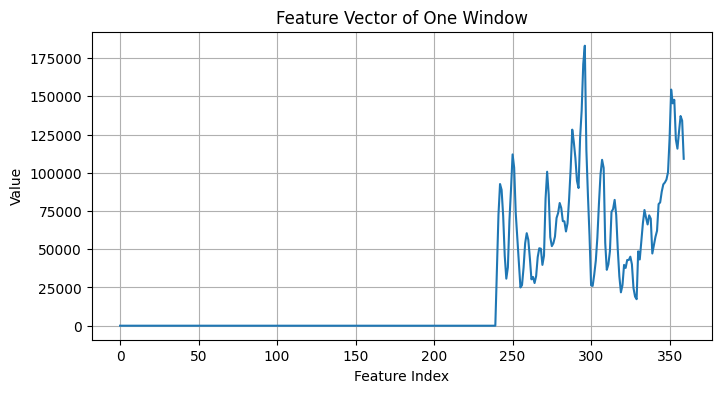

In [ ]:
window = X_ds[0]

plt.figure(figsize=(8,4))avi sta
plt.plot(window)
plt.title("Feature Vector of One Window")
plt.xlabel("Feature Index")
plt.ylabel("Value")
plt.grid()
plt.show()


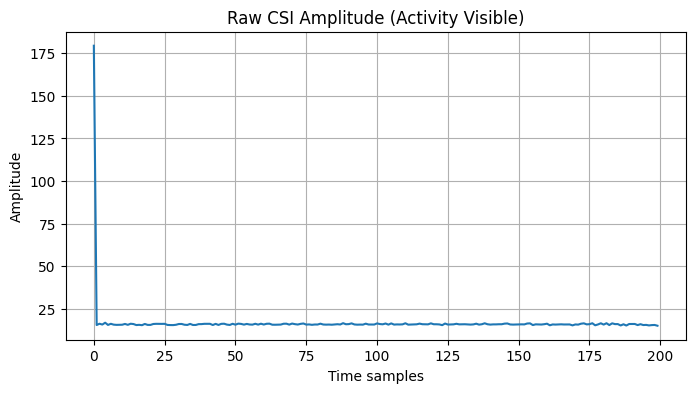

In [ ]:
raw_csi = pd.read_csv("/content/DatasetCSV/Subj-1_Area-2_Act-7.csv", header=None).values  # (time, subcarriers)

# Take one window
window_raw = raw_csi[0:200, :]  # 200 samples × 360 subcarriers

# Average across subcarriers
signal = np.mean(window_raw, axis=1)

plt.figure(figsize=(8,4))
plt.plot(signal)
plt.title("Raw CSI Amplitude (Activity Visible)")
plt.xlabel("Time samples")
plt.ylabel("Amplitude")
plt.grid()
plt.show()


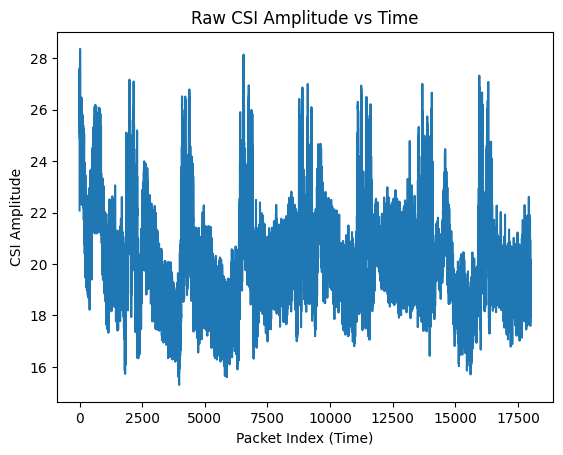

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load CSI data
df = pd.read_csv("/content/DatasetCSV/Subj-1_Area-2_Act-7.csv")

# Take one subcarrier (e.g., column index 10)
csi_amplitude = df.iloc[:, 10]

# Plot raw CSI amplitude
plt.figure()
plt.plot(csi_amplitude)
plt.xlabel("Packet Index (Time)")
plt.ylabel("CSI Amplitude")
plt.title("Raw CSI Amplitude vs Time")
plt.show()


Testing on other dataset


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
BASE_PATH = "/content/drive/MyDrive/UT-HAR wifidataset"

DATA_PATH = f"{BASE_PATH}/data"
LABEL_PATH = f"{BASE_PATH}/label"


In [ ]:
import numpy as np

# Load data
X_train = np.load(f"{DATA_PATH}/X_train.csv", allow_pickle=True)
X_val   = np.load(f"{DATA_PATH}/X_val.csv", allow_pickle=True)
X_test  = np.load(f"{DATA_PATH}/X_test.csv", allow_pickle=True)

# Load labels
y_train = np.load(f"{LABEL_PATH}/y_train.csv", allow_pickle=True)
y_val   = np.load(f"{LABEL_PATH}/y_val.csv", allow_pickle=True)
y_test  = np.load(f"{LABEL_PATH}/y_test.csv", allow_pickle=True)

print("Original shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)


Original shapes:
Train: (3977, 250, 90) (3977,)
Val  : (496, 250, 90) (496,)
Test : (500, 250, 90) (500,)


In [ ]:
from skimage.transform import resize

def resize_ut_har(X, target_size=(32, 32)):
    X_resized = []
    for sample in X:
        resized = resize(sample, target_size,
                          mode='reflect',
                          anti_aliasing=True)
        X_resized.append(resized)
    return np.array(X_resized)


In [ ]:
X_test_resized = resize_ut_har(X_test)
print("After resize:", X_test_resized.shape)


After resize: (500, 32, 32)


In [ ]:
# Convert to float32
X_test_resized = X_test_resized.astype("float32")

# Add channel dimension
X_test_resized = X_test_resized[..., np.newaxis]

print("Final UT-HAR test shape:", X_test_resized.shape)


Final UT-HAR test shape: (500, 32, 32, 1)


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/wifi_activity_cnn_model.h5"
)


In [ ]:
loss, acc = model.evaluate(X_test_resized, y_test, verbose=1)
print("UT-HAR Cross-Dataset Accuracy:", acc * 100)


ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(None,), output.shape=(None, 10)

In [ ]:
from tensorflow.keras.utils import to_categorical

# Convert UT-HAR labels to one-hot with 10 classes
y_test_cat = to_categorical(y_test, num_classes=10)

print("y_test_cat shape:", y_test_cat.shape)


y_test_cat shape: (500, 10)


In [ ]:
loss, acc = model.evaluate(X_test_resized, y_test_cat, verbose=1)
print("UT-HAR Cross-Dataset Accuracy:", acc * 100)


ValueError: Creating variables on a non-first call to a function decorated with tf.function.

In [ ]:
import tensorflow as tf
tf.keras.backend.clear_session()


In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/wifi_activity_cnn_model.h5",
    compile=False
)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
loss, acc = model.evaluate(X_test_resized, y_test_cat, verbose=1)
print("UT-HAR Cross-Dataset Accuracy:", acc * 100)


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.3438 - loss: 184.1843
UT-HAR Cross-Dataset Accuracy: 12.999999523162842


UCI-HAR dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np

BASE_PATH = "/content/drive/MyDrive/UCI-HAR Dataset/"

X_train = np.loadtxt(BASE_PATH + "train/X_train.txt")
y_train = np.loadtxt(BASE_PATH + "train/y_train.txt")

X_test = np.loadtxt(BASE_PATH + "test/X_test.txt")
y_test = np.loadtxt(BASE_PATH + "test/y_test.txt")

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(7352, 561) (7352,)
(2947, 561) (2947,)


In [ ]:
import numpy as np

BASE_PATH = "/content/drive/MyDrive/UCI-HAR Dataset"

X_test = np.loadtxt(f"{BASE_PATH}/test/X_test.txt")
y_test = np.loadtxt(f"{BASE_PATH}/test/y_test.txt")

# Convert labels from 1–6 → 0–5
y_test = y_test.astype(int) - 1

print("Original X_test shape:", X_test.shape)   # (N, 561)
print("Original y_test shape:", y_test.shape)


Original X_test shape: (2947, 561)
Original y_test shape: (2947,)


convert 561 -> 2D matrix

In [ ]:
def reshape_uci_to_2d(X):
    X_2d = []
    for sample in X:
        padded = np.pad(sample, (0, 575 - 561))  # pad zeros
        reshaped = padded.reshape(23, 25)
        X_2d.append(reshaped)
    return np.array(X_2d)

X_test_2d = reshape_uci_to_2d(X_test)
print("After reshape:", X_test_2d.shape)  # (N, 23, 25)


After reshape: (2947, 23, 25)


Resize to CNN input (32*32)

In [ ]:
from skimage.transform import resize

def resize_to_32(X):
    resized = []
    for sample in X:
        r = resize(sample, (32, 32), mode='reflect', anti_aliasing=True)
        resized.append(r)
    return np.array(resized)

X_test_resized = resize_to_32(X_test_2d)
print("After resize:", X_test_resized.shape)


After resize: (2947, 32, 32)


In [ ]:
X_test_resized = X_test_resized.astype("float32")
X_test_resized = X_test_resized[..., np.newaxis]

print("Final input shape:", X_test_resized.shape)


Final input shape: (2947, 32, 32, 1)


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/wifi_activity_cnn_model.h5"
)

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,236 (1.36 MB)

 Trainable params: 356,234 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
loss, acc = model.evaluate(X_test_resized, y_test, verbose=1)
print("UCI-HAR Cross-Dataset Accuracy:", acc * 100)


ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(None,), output.shape=(None, 10)

In [ ]:
from tensorflow.keras.utils import to_categorical

y_test_cat = to_categorical(y_test, num_classes=10)

print("y_test_cat shape:", y_test_cat.shape)


y_test_cat shape: (2947, 10)


In [ ]:
loss, acc = model.evaluate(X_test_resized, y_test_cat, verbose=1)
print("UCI-HAR Cross-Dataset Accuracy:", acc * 100)


ValueError: Creating variables on a non-first call to a function decorated with tf.function.

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/wifi_activity_cnn_model.h5"
)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
loss, acc = model.evaluate(X_test_resized, y_test_cat, verbose=1)
print("UCI-HAR Cross-Dataset Accuracy:", acc * 100)


93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.3048 - loss: 29.0286
UCI-HAR Cross-Dataset Accuracy: 31.184256076812744


Train on UT-HAR dataset and test on UCI-HAR dataset


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from skimage.transform import resize
from tensorflow.keras.utils import to_categorical


In [ ]:
BASE_PATH = "/content/drive/MyDrive/UT-HAR wifidataset"

X_train = np.load(f"{BASE_PATH}/data/X_train.csv", allow_pickle=True)
y_train = np.load(f"{BASE_PATH}/label/y_train.csv", allow_pickle=True)

X_test = np.load(f"{BASE_PATH}/data/X_test.csv", allow_pickle=True)
y_test = np.load(f"{BASE_PATH}/label/y_test.csv", allow_pickle=True)

print(X_train.shape, X_test.shape)


(3977, 250, 90) (500, 250, 90)


In [ ]:
def resize_data(X, target=(64, 64)):
    out = []
    for x in X:
        out.append(resize(x, target, mode="reflect", anti_aliasing=True))
    return np.array(out)

X_train_r = resize_data(X_train)
X_test_r  = resize_data(X_test)

X_train_r = X_train_r.astype("float32")[..., np.newaxis]
X_test_r  = X_test_r.astype("float32")[..., np.newaxis]



In [ ]:
num_classes = len(np.unique(y_train))

y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)


In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,1)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,479 (6.20 MB)

 Trainable params: 1,625,479 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_r, y_train_cat,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_r, y_test_cat)
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 0.2958 - loss: 3.3226 - val_accuracy: 0.5860 - val_loss: 1.1886
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5933 - loss: 1.1289 - val_accuracy: 0.7360 - val_loss: 0.8101
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6812 - loss: 0.8657 - val_accuracy: 0.7580 - val_loss: 0.5984
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7700 - loss: 0.6278 - val_accuracy: 0.8080 - val_loss: 0.5040
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7999 - loss: 0.5448 - val_accuracy: 0.8300 - val_loss: 0.4154
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8406 - loss: 0.4499 - val_accuracy: 0.7700 - val_loss: 0.5136
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8481 - loss: 0.4071 - val_accuracy: 0.8340 - val_loss: 0.4471
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8542 - loss: 0.3924 - val_accuracy: 

In [ ]:
train_loss, train_acc = model.evaluate(X_train_r, y_train_cat, verbose=0)
test_loss, test_acc   = model.evaluate(X_test_r, y_test_cat, verbose=0)

print("UT-HAR Training Accuracy:", train_acc * 100)
print("UT-HAR Test Accuracy:", test_acc * 100)



UT-HAR Training Accuracy: 98.31531047821045
UT-HAR Test Accuracy: 91.79999828338623


In [ ]:
model.save("/content/drive/MyDrive/UT_HAR_trained_CNN.h5")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
UCI_PATH = "/content/drive/MyDrive/UCI-HAR Dataset"

X_uci = np.loadtxt(f"{UCI_PATH}/test/X_test.txt")
y_uci = np.loadtxt(f"{UCI_PATH}/test/y_test.txt") - 1  # labels start from 1

print(X_uci.shape)


(2947, 561)


In [ ]:
def reshape_uci(X, target=(64,64)):
    imgs = []
    for row in X:
        padded = np.pad(row, (0, target[0]*target[1] - len(row)))
        img = padded.reshape(target)
        imgs.append(img)
    return np.array(imgs)

X_uci_r = reshape_uci(X_uci)
X_uci_r = X_uci_r.astype("float32")[..., np.newaxis]


In [ ]:
y_uci_cat = to_categorical(y_uci, num_classes)


In [ ]:
uci_loss, uci_acc = model.evaluate(X_uci_r, y_uci_cat, verbose=1)

print("UCI-HAR Cross-Dataset Accuracy:", uci_acc * 100)


93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.1750 - loss: 6.6427
UCI-HAR Cross-Dataset Accuracy: 18.22192072868347


Train on UT-HAR and test on WISDM lab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from skimage.transform import resize
from tensorflow.keras.utils import to_categorical


In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/UT_HAR_trained_CNN.h5"
)

#model.summary()


In [ ]:
WISDM_PATH = "/content/drive/MyDrive/WISDM lab dataset"

df = pd.read_csv(f"{WISDM_PATH}/test.csv")

print(df.head())
print(df['Activity'].value_counts())


   acc_x  acc_y  acc_z    timestamp  Activity
0  -1.31  10.61  -0.69  2696.602336         0
1  -1.14   9.38   1.46  2696.652293         0
2  -0.34   9.43   0.42  2696.702312         0
3  -0.34  10.46  -0.89  2696.752269         0
4   1.12  10.23  -1.53  2696.802318         0
Activity
5    93686
1    62866
4    30115
0    20783
2    10086
3     8177
Name: count, dtype: int64


In [ ]:
df = df[["acc_x", "acc_y", "acc_z", "Activity"]]


In [ ]:
WINDOW_SIZE = 128
STEP_SIZE = 64

def create_windows_wisdm(df):
    X, y = [], []

    data = df[["acc_x", "acc_y", "acc_z"]].values
    labels = df["Activity"].values

    for i in range(0, len(data) - WINDOW_SIZE, STEP_SIZE):
        window = data[i:i+WINDOW_SIZE]
        label = np.bincount(labels[i:i+WINDOW_SIZE]).argmax()

        X.append(window)
        y.append(label)

    return np.array(X), np.array(y)

X_wisdm, y_wisdm = create_windows_wisdm(df)

print("WISDM windows shape:", X_wisdm.shape)
print("WISDM labels shape:", y_wisdm.shape)


WISDM windows shape: (3525, 128, 3)
WISDM labels shape: (3525,)


In [ ]:
def reshape_to_image(X, target_size=(32, 32)):
    X_img = []
    for sample in X:
        flat = sample.flatten()        # (128×3 = 384)
        img = resize(flat.reshape(-1, 1), target_size)
        X_img.append(img)
    return np.array(X_img)

X_wisdm_img = reshape_to_image(X_wisdm)

print("Reshaped WISDM:", X_wisdm_img.shape)


Reshaped WISDM: (3525, 32, 32)


In [ ]:
X_wisdm_img = X_wisdm_img.astype("float32")
X_wisdm_img = X_wisdm_img[..., np.newaxis]

y_wisdm_cat = to_categorical(y_wisdm, num_classes=10)

print("Final input shape:", X_wisdm_img.shape)
print("Final label shape:", y_wisdm_cat.shape)


Final input shape: (3525, 32, 32, 1)
Final label shape: (3525, 10)


In [ ]:
loss, acc = model.evaluate(X_wisdm_img, y_wisdm_cat, verbose=1)

print("WISDM Cross-Dataset Accuracy:", acc * 100)


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense_2" is incompatible with the layer: expected axis -1 of input shape to have value 12544, but received input with shape (None, 2304)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 32, 32, 1), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>